In [1]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [2]:
# Load and preprocess MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape((-1, 28 * 28))
x_test = x_test.reshape((-1, 28 * 28))

In [3]:
# Define autoencoder
encoding_dim = 32

inputs = keras.Input(shape=(784,))
encoded = layers.Dense(128, activation="relu")(inputs)
encoded = layers.Dense(encoding_dim, activation="relu")(encoded)

decoded = layers.Dense(128, activation="relu")(encoded)
decoded = layers.Dense(784, activation="sigmoid")(decoded)

autoencoder = keras.Model(inputs, decoded)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

In [4]:
# Train
autoencoder.fit(
    x_train, x_train,
    epochs=1,
    batch_size=32,
    shuffle=True,
    validation_data=(x_test, x_test)
)

1875/1875 [==============================] - 3s 2ms/step - loss: 0.1372 - val_loss: 0.1027


In [5]:
# Reconstruct test images
reconstructions = autoencoder.predict(x_test)

313/313 [==============================] - 0s 455us/step


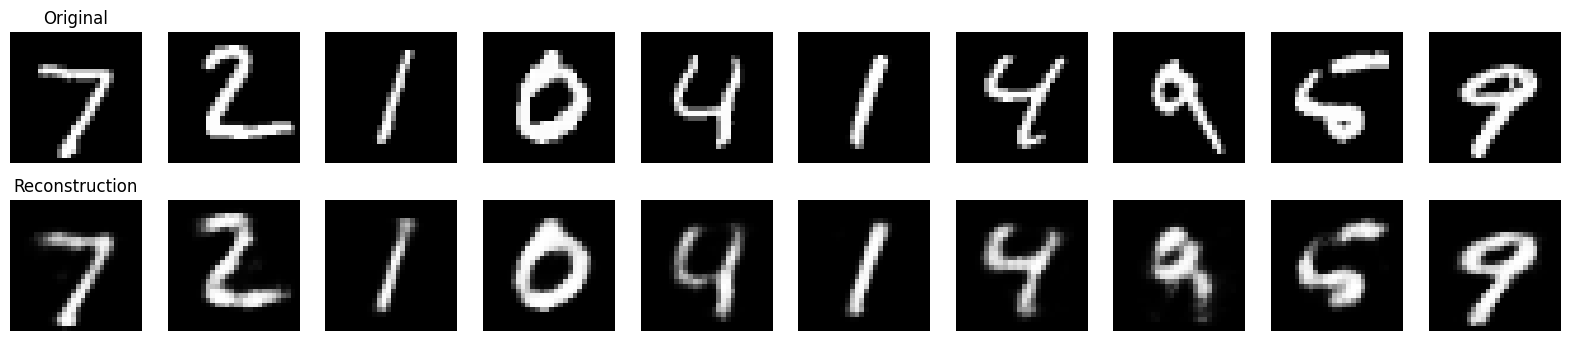

In [7]:
# Show originals and reconstructions
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Original")

    # reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructions[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Reconstruction")

plt.show()

# Left as an exercise for the reader

In [8]:
# Add noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

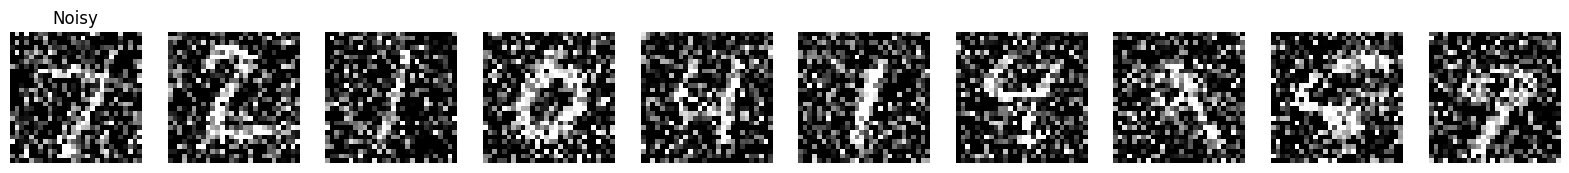

In [9]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
    if i == 0:
        ax.set_title("Noisy")
